In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('Social_Network_Ads.csv')

In [4]:
df=df.iloc[:,2:]

In [5]:
df.sample(10)

,Age,EstimatedSalary,Purchased
230,35,147000,1
252,48,134000,1
393,60,42000,1
242,50,88000,1
240,42,149000,1
359,42,54000,0
65,24,58000,0
395,46,41000,1
125,39,61000,0
307,47,113000,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [7]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=42)

In [9]:
X_train.shape, X_test.shape 

((280, 2), (120, 2))

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
scaler.mean_

array([3.75750000e+01, 7.05892857e+04])

In [15]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [16]:
X_train_scaled

,Age,EstimatedSalary
0,-0.842522,0.130156
1,0.041758,0.277702
2,0.729530,-1.315791
3,1.613809,1.103957
4,0.827784,-1.404318
...,...,...
275,-1.333788,-1.286281
276,-1.137281,-1.050209
277,0.533024,1.841685
278,0.140011,0.189175


In [17]:
np.round(X_train_scaled.describe(),2)

,Age,EstimatedSalary
count,280.00,280.00
mean,-0.00,0.00
std,1.00,1.00
min,-1.92,-1.64
25%,-0.74,-0.78
50%,-0.06,0.01
75%,0.73,0.51
max,2.20,2.34


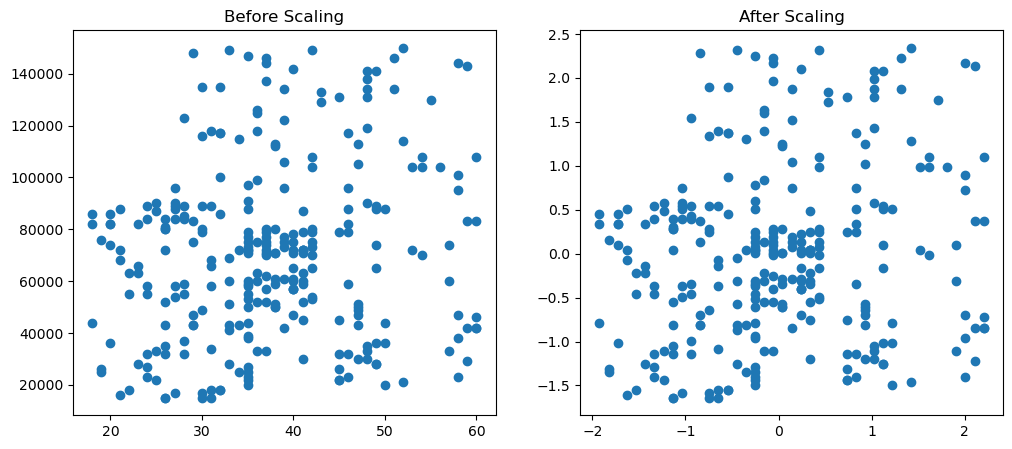

In [18]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,5))

ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'])
ax2.set_title('After Scaling')
plt.show()

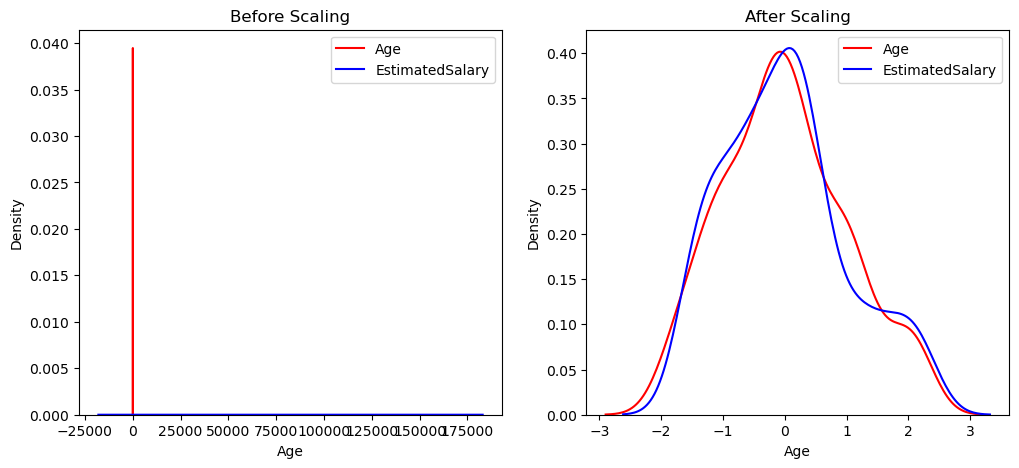

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Age'], fill=False, color='r', label='Age', ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], fill=False, color='b', label='EstimatedSalary', ax=ax1)
ax1.legend()

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled['Age'], fill=False, color='r', label='Age', ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], fill=False, color='b', label='EstimatedSalary', ax=ax2)
ax2.legend()

plt.show()